In [5]:
import warnings
warnings.filterwarnings('ignore')
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix
)
from scipy.stats import f_oneway

In [3]:
df = pd.read_csv('nba_merged_clean.csv')

In [6]:
print("=== Dataset Overview ===")
print(f"Shape: {df.shape}")
print(f"Seasons: {df['season'].min()} – {df['season'].max()}")
print(f"\nPosition distribution (raw):\n{df['position'].value_counts()}")

=== Dataset Overview ===
Shape: (25307, 37)
Seasons: 1950 – 2026

Position distribution (raw):
position
SG    5292
PF    5082
C     4940
SF    4900
PG    4689
Name: count, dtype: int64


In [7]:
df['position_raw'] = df['position']
df['position'] = df['position'].astype(str).str.split('-').str[0].str.strip()
 
# Map 5 positions → 3 groups (Guard / Forward / Center)
pos_map = {
    'PG': 'Guard',  'SG': 'Guard',
    'SF': 'Forward','PF': 'Forward',
    'C':  'Center'
}
df['pos_group'] = df['position'].map(pos_map)
 
# Drop rows where position is unknown/NaN
df = df[df['pos_group'].notna()].copy()
 
print("\n=== After cleaning ===")
print(df['pos_group'].value_counts())


=== After cleaning ===
pos_group
Forward    9982
Guard      9981
Center     4940
Name: count, dtype: int64


In [13]:
FEATURES = [
    'pts_per_game',     # Scoring
    'ast_per_game',     # Playmaking
    'trb_per_game',     # Rebounding (total)
    'blk_per_game',     # Rim protection
    'stl_per_game',     # Perimeter defense
    'x3pa_per_game',    # 3-point attempts
    'ft_percent',       # Free throw % (proxy for guard/big)
    'fg_percent',       # FG efficiency
    'tov_per_game',     # Turnovers (usage proxy)
    'mp_per_game',      # Minutes
]

In [14]:
# Drop rows with missing values in selected features
df_model = df[FEATURES + ['pos_group', 'player_name', 'season']].dropna()
 
print(f"\nRows used for modelling: {len(df_model)}")
print(f"Position breakdown:\n{df_model['pos_group'].value_counts()}")
 
X = df_model[FEATURES].values
y_true_labels = df_model['pos_group'].values


Rows used for modelling: 24903
Position breakdown:
pos_group
Forward    9982
Guard      9981
Center     4940
Name: count, dtype: int64


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

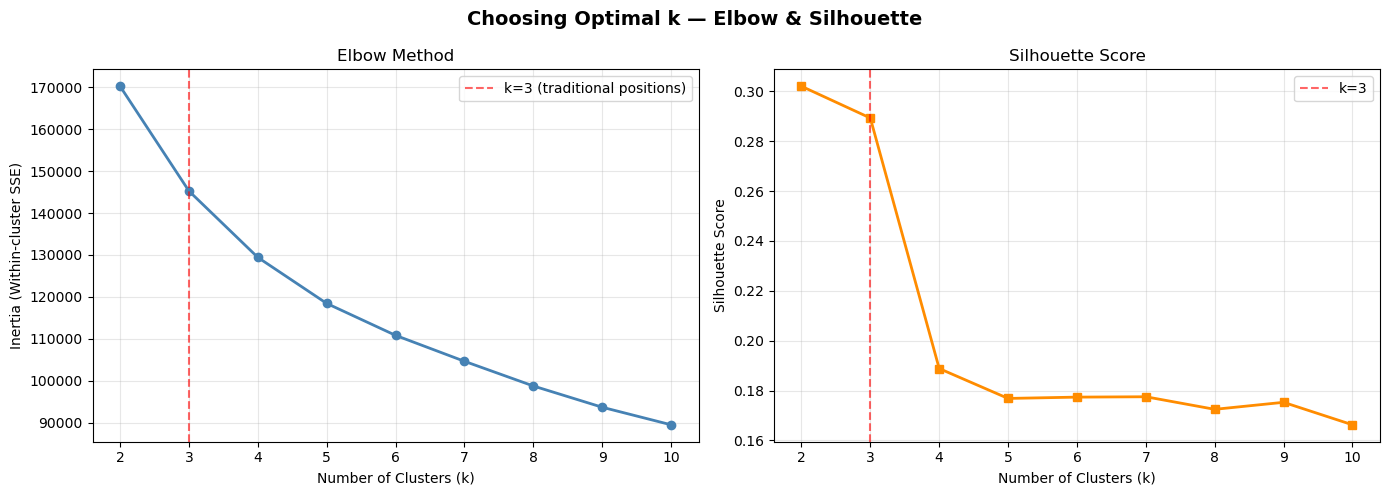

Saved: elbow_silhouette.png


In [16]:
inertia_values = []
silhouette_values = []
k_range = range(2, 11)
 
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Choosing Optimal k — Elbow & Silhouette', fontsize=14, fontweight='bold')
 
axes[0].plot(k_range, inertia_values, 'o-', color='steelblue', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].set_title('Elbow Method')
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='k=3 (traditional positions)')
axes[0].legend()
axes[0].grid(alpha=0.3)
 
axes[1].plot(k_range, silhouette_values, 's-', color='darkorange', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='k=3')
axes[1].legend()
axes[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: elbow_silhouette.png")

In [17]:
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_k3 = km3.fit_predict(X_scaled)
sil_k3 = silhouette_score(X_scaled, labels_k3)
 
# --- k=5 (traditional 5-position structure) ---
km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_k5 = km5.fit_predict(X_scaled)
sil_k5 = silhouette_score(X_scaled, labels_k5)
 
print(f"\n=== K-Means Results ===")
print(f"k=3 Silhouette Score: {sil_k3:.4f}")
print(f"k=5 Silhouette Score: {sil_k5:.4f}")


=== K-Means Results ===
k=3 Silhouette Score: 0.2893
k=5 Silhouette Score: 0.1768
